This notebook benchmarks velocity methods for trajectory accuracy. Notebooks with "3_" prefix should be run before it.

In [1]:
import ArchVelo as av

In [2]:
import numpy as np
import pandas as pd

import scanpy as sc
import scvelo as scv
import multivelo as mv

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data_outdir = 'processed_data/'
adata_rna = sc.read_h5ad(data_outdir+'adata_rna.h5ad')

## Load other methods

In [4]:
model_outdir = 'modeling_results/'

In [5]:
num_comps = 9


In [6]:
SCV_result = sc.read_h5ad(model_outdir+'scvelo_result.h5ad')
MV_result = sc.read_h5ad(model_outdir+'multivelo_result.h5ad')
AA_result = sc.read_h5ad(model_outdir+'archvelo_result.h5ad')
DV_result = sc.read_h5ad(model_outdir+'DeepVelo_result.h5ad')
VV_result = sc.read_h5ad(model_outdir+'VeloVI_result.h5ad')
CF_result = sc.read_h5ad(model_outdir+'Cell2Fate_result.h5ad')
TF_result = sc.read_h5ad(model_outdir+'TFVelo_result.h5ad')


In [7]:
for dat in [CF_result, TF_result]:
    dat.obs['cell_type'] = dat.obs['clusters']
    dat.uns['cell_type_colors'] = dat.uns['clusters_colors']
    dat.obsm['X_umap'] = AA_result.obsm['X_umap']

In [8]:
multi_results = [AA_result, MV_result]
rna_results = [SCV_result, DV_result, VV_result, TF_result, CF_result]
all_results = multi_results+rna_results

In [9]:
multi_aliases = ['ArchVelo', 'MultiVelo']
rna_aliases = ['scVelo', 'DeepVelo', 'VeloVI', 'TFVelo',  'Cell2Fate']
aliases = multi_aliases+rna_aliases

In [10]:
multi_vel_keys = ['velo_s_norm']*2
rna_vel_keys = ['velocity']*4+['Velocity']
vel_keys = multi_vel_keys + rna_vel_keys

In [11]:
import os
fig_outdir = 'figures/'
os.makedirs(fig_outdir, exist_ok = True)


In [12]:
celltype_name = 'cell_type'

# Velocity fields

In [13]:
sns.set(style = 'ticks', font_scale = 1)

computing velocity embedding
    finished (0:00:02) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


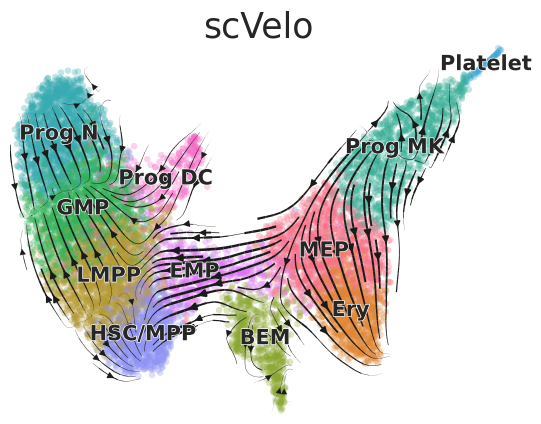

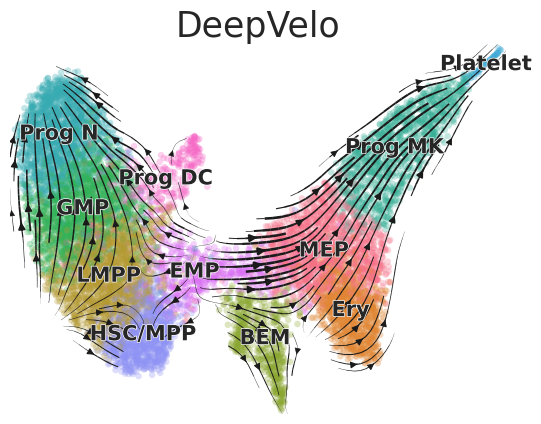

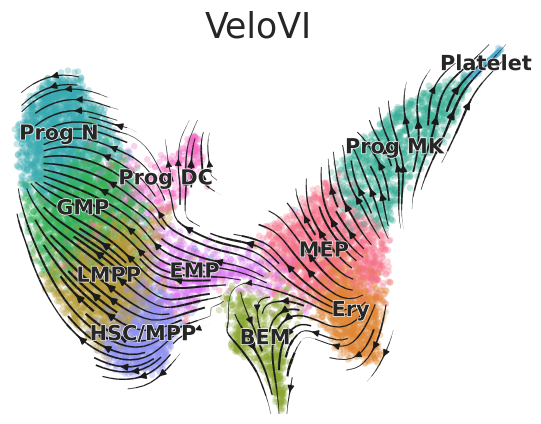

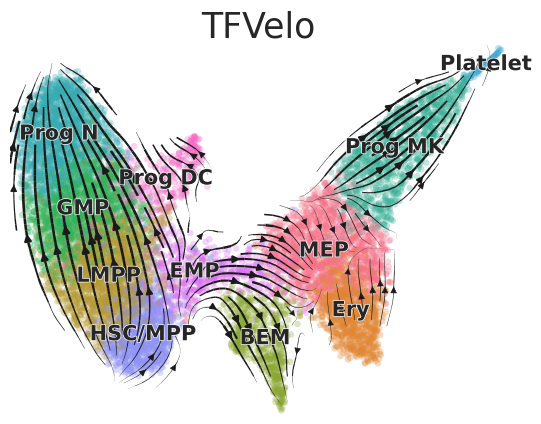

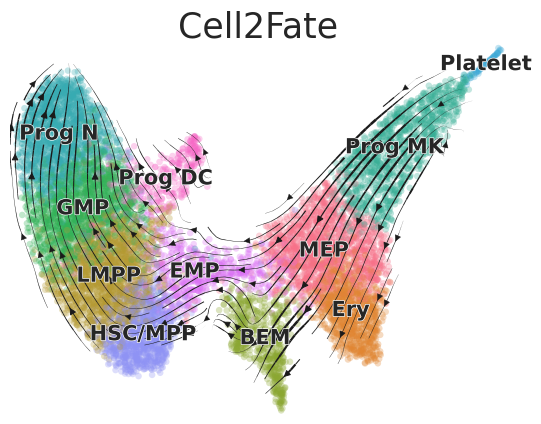

In [14]:
i = 0
for dat in rna_results:
    cur_vel_key = rna_vel_keys[i]
    cur_alias = rna_aliases[i]
    if cur_vel_key+'_graph' not in dat.uns.keys():
        print('calculating graph for '+cur_alias)
        scv.tl.velocity_graph(dat, vkey = cur_vel_key)
    scv.pl.velocity_embedding_stream(dat, show=False, color = celltype_name, 
                                 #palette = pal,
                                 title = cur_alias, vkey = cur_vel_key,
                                 fontsize = 25, legend_fontsize = 15)
    plt.savefig(fig_outdir+cur_alias+'_results.png', dpi = 500, transparent = True)
    plt.savefig(fig_outdir+cur_alias+'_results.svg', dpi = 500, transparent = True)
    i+=1

calculating graph for ArchVelo
computing velocity graph (using 1/128 cores)


  0%|          | 0/10935 [00:00<?, ?cells/s]

    finished (0:01:20) --> added 
    'velo_s_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 8 regions of root cells and 1 region of end points .
    finished (0:00:02) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:04) --> added 
    'latent_time', shared time (adata.obs)
computing velocity embedding
    finished (0:00:02) --> added
    'velo_s_norm_umap', embedded velocity vectors (adata.obsm)
calculating graph for MultiVelo
computing velocity graph (using 1/128 cores)


  0%|          | 0/10935 [00:00<?, ?cells/s]

    finished (0:00:56) --> added 
    'velo_s_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 7 regions of root cells and 1 region of end points .
    finished (0:00:03) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:02) --> added 
    'latent_time', shared time (adata.obs)
computing velocity embedding
    finished (0:00:02) --> added
    'velo_s_norm_umap', embedded velocity vectors (adata.obsm)


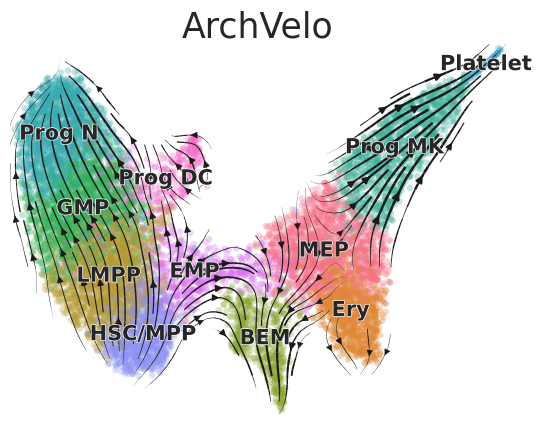

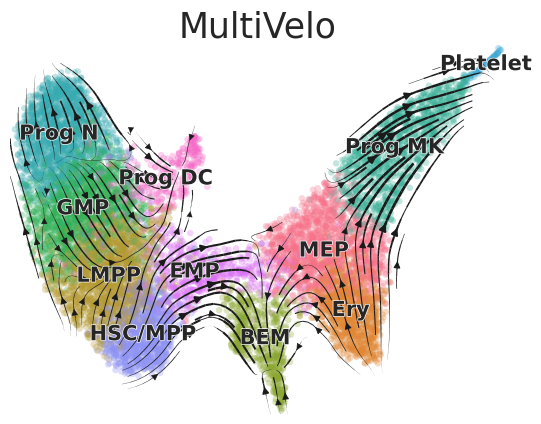

In [15]:
i = 0
for dat in multi_results:
    cur_vel_key = multi_vel_keys[i]
    cur_alias = multi_aliases[i]
    #if cur_vel_key+'_graph' not in dat.uns.keys():
    print('calculating graph for '+cur_alias)
    mv.velocity_graph(dat)
    mv.latent_time(dat)
    mv.velocity_embedding_stream(dat, show=False,
                                 color = celltype_name, 
                                 title = cur_alias,
                                 fontsize = 25, legend_fontsize = 15)
    plt.savefig(fig_outdir+cur_alias+'_results.png', dpi = 500, transparent = True)
    plt.savefig(fig_outdir+cur_alias+'_results.svg', dpi = 500, transparent = True)
    i+=1

# CBD on aggregated edges

In [16]:
multi_results = [AA_result, MV_result]
rna_results = [SCV_result, DV_result, VV_result, TF_result, CF_result]
all_results = multi_results+rna_results

In [17]:
inds = np.array([[i]+list(np.nonzero(x)[1]) for (i,x) in enumerate(adata_rna.obsp['distances'])])
for dat in all_results:
    dat.uns['neighbors']['indices'] = inds

In [18]:
edges = [('HSC/MPP', 'LMPP'), 
         ('LMPP', 'GMP'),
         ('GMP', 'Prog N'), 
         ('LMPP', 'Prog DC'),    
         ('HSC/MPP', 'EMP'), 
         ('EMP', 'MEP'),
         ('EMP', 'BEM'),
         ('MEP', 'BEM'),
         ('MEP', 'Ery'),
         ('MEP', 'Prog MK'),
         ('Prog MK', 'Platelet')]
        

In [19]:
cl_keys = [celltype_name]*len(aliases)

In [20]:
CBCs = {}

In [21]:
for [k, vk, cl, res] in zip(aliases, vel_keys, cl_keys, all_results):
    CBCs[k] = av.cross_boundary_correctness(res, cl, vk, edges, x_emb = "X_umap", return_raw = True)

In [22]:
hue_order = aliases

In [23]:
pal = ['#E4504F', '#566CB3', '#ACACAC', '#5CBA62', '#F2A138', '#A163D6', '#2CB1A6'] 

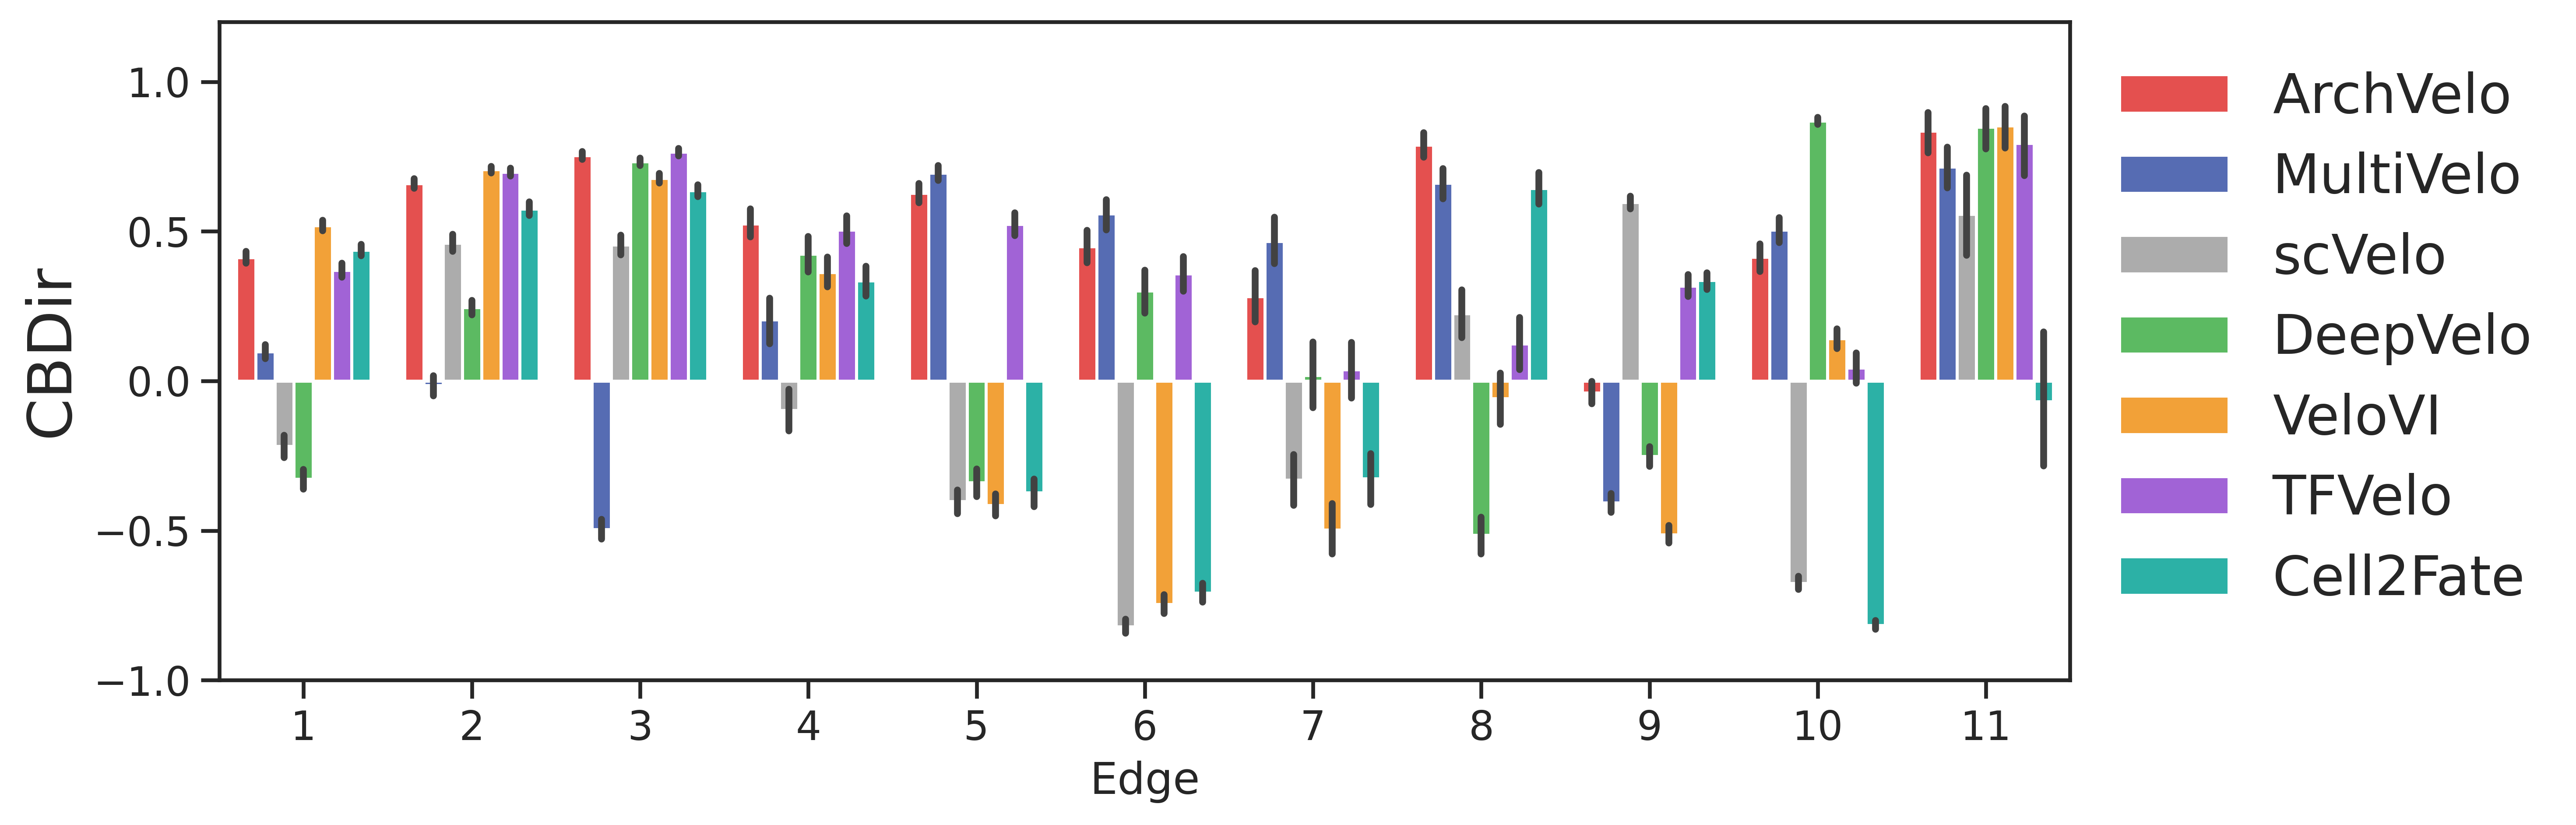

In [24]:
sns.set(style = 'ticks', font_scale = 1.2)
plt.figure(figsize = (12,4), dpi = 500)
methods = CBCs.keys()
all_CBCs = pd.concat([pd.concat([pd.Series(CBCs[met][k]) for k in CBCs[met].keys()],
         keys = [str(x[0]) for x in list(zip(CBCs[met].keys()))]) for met in methods],
          keys = methods, axis = 0, join = 'outer').reset_index()
all_CBCs.columns = ['Method', 'Edge', 'Cell','CBD']
sns.barplot(data = all_CBCs, 
            y = 'CBD',
            x = 'Edge',
            #order = edge_order,
            hue = 'Method', 
             palette = pal,#palette = np.array(sns.color_palette('hls',4))[[0,2,3]], #swap_axes = True,
             hue_order = hue_order,
           saturation = 1)#, order = edges)
plt.xticks(ticks = range(len(edges)),labels = [str(x) for x in range(1,1+len(edges))])
plt.ylabel('CBDir', fontsize = 20)
plt.xlabel('Edge')
plt.legend(frameon = False, fontsize = 18, bbox_to_anchor = (1,1))
plt.ylim(-1, 1.2)
plt.tight_layout()
plt.savefig(fig_outdir+'CBCs_full.png', dpi = 500, transparent = True)
plt.savefig(fig_outdir+'CBCs_full.svg', dpi = 500, transparent = True)

In [32]:
from tabulate import tabulate

all_CBCs_copy = all_CBCs.copy()
all_CBCs_copy ['full_edge'] = all_CBCs_copy ['Edge'].copy()
all_CBCs_copy['Edge'] = pd.factorize(all_CBCs_copy['Edge'])[0]+1
fdr_level = 0.01
result_table =  av.create_relative_performance_table(all_CBCs_copy, 
                                            control_method='ArchVelo',
                                                alpha=fdr_level)
result_table.index.names = ['Edge']

print("--- Edge by Method Performance Table (Star indicates significant outperformance) ---")
print(tabulate(result_table.iloc[:, 1:].replace('★', '✱'), headers='keys', tablefmt='simple_grid', stralign='center',
              ))

--- Edge by Method Performance Table (Star indicates significant outperformance) ---
┌────────┬─────────────┬──────────┬────────────┬──────────┬──────────┬─────────────┐
│   Edge │  MultiVelo  │  scVelo  │  DeepVelo  │  VeloVI  │  TFVelo  │  Cell2Fate  │
├────────┼─────────────┼──────────┼────────────┼──────────┼──────────┼─────────────┤
│      1 │      ✱      │    ✱     │     ✱      │    -     │    ✱     │     NS      │
├────────┼─────────────┼──────────┼────────────┼──────────┼──────────┼─────────────┤
│      2 │      ✱      │    ✱     │     ✱      │    NS    │    -     │     NS      │
├────────┼─────────────┼──────────┼────────────┼──────────┼──────────┼─────────────┤
│      3 │      ✱      │    ✱     │     ✱      │    ✱     │    NS    │      ✱      │
├────────┼─────────────┼──────────┼────────────┼──────────┼──────────┼─────────────┤
│      4 │      ✱      │    ✱     │     ✱      │    ✱     │    ✱     │      ✱      │
├────────┼─────────────┼──────────┼────────────┼──────────┼──────

In [26]:
edge_means = all_CBCs.groupby(['Method', 'Edge'])['CBD'].mean().reset_index()

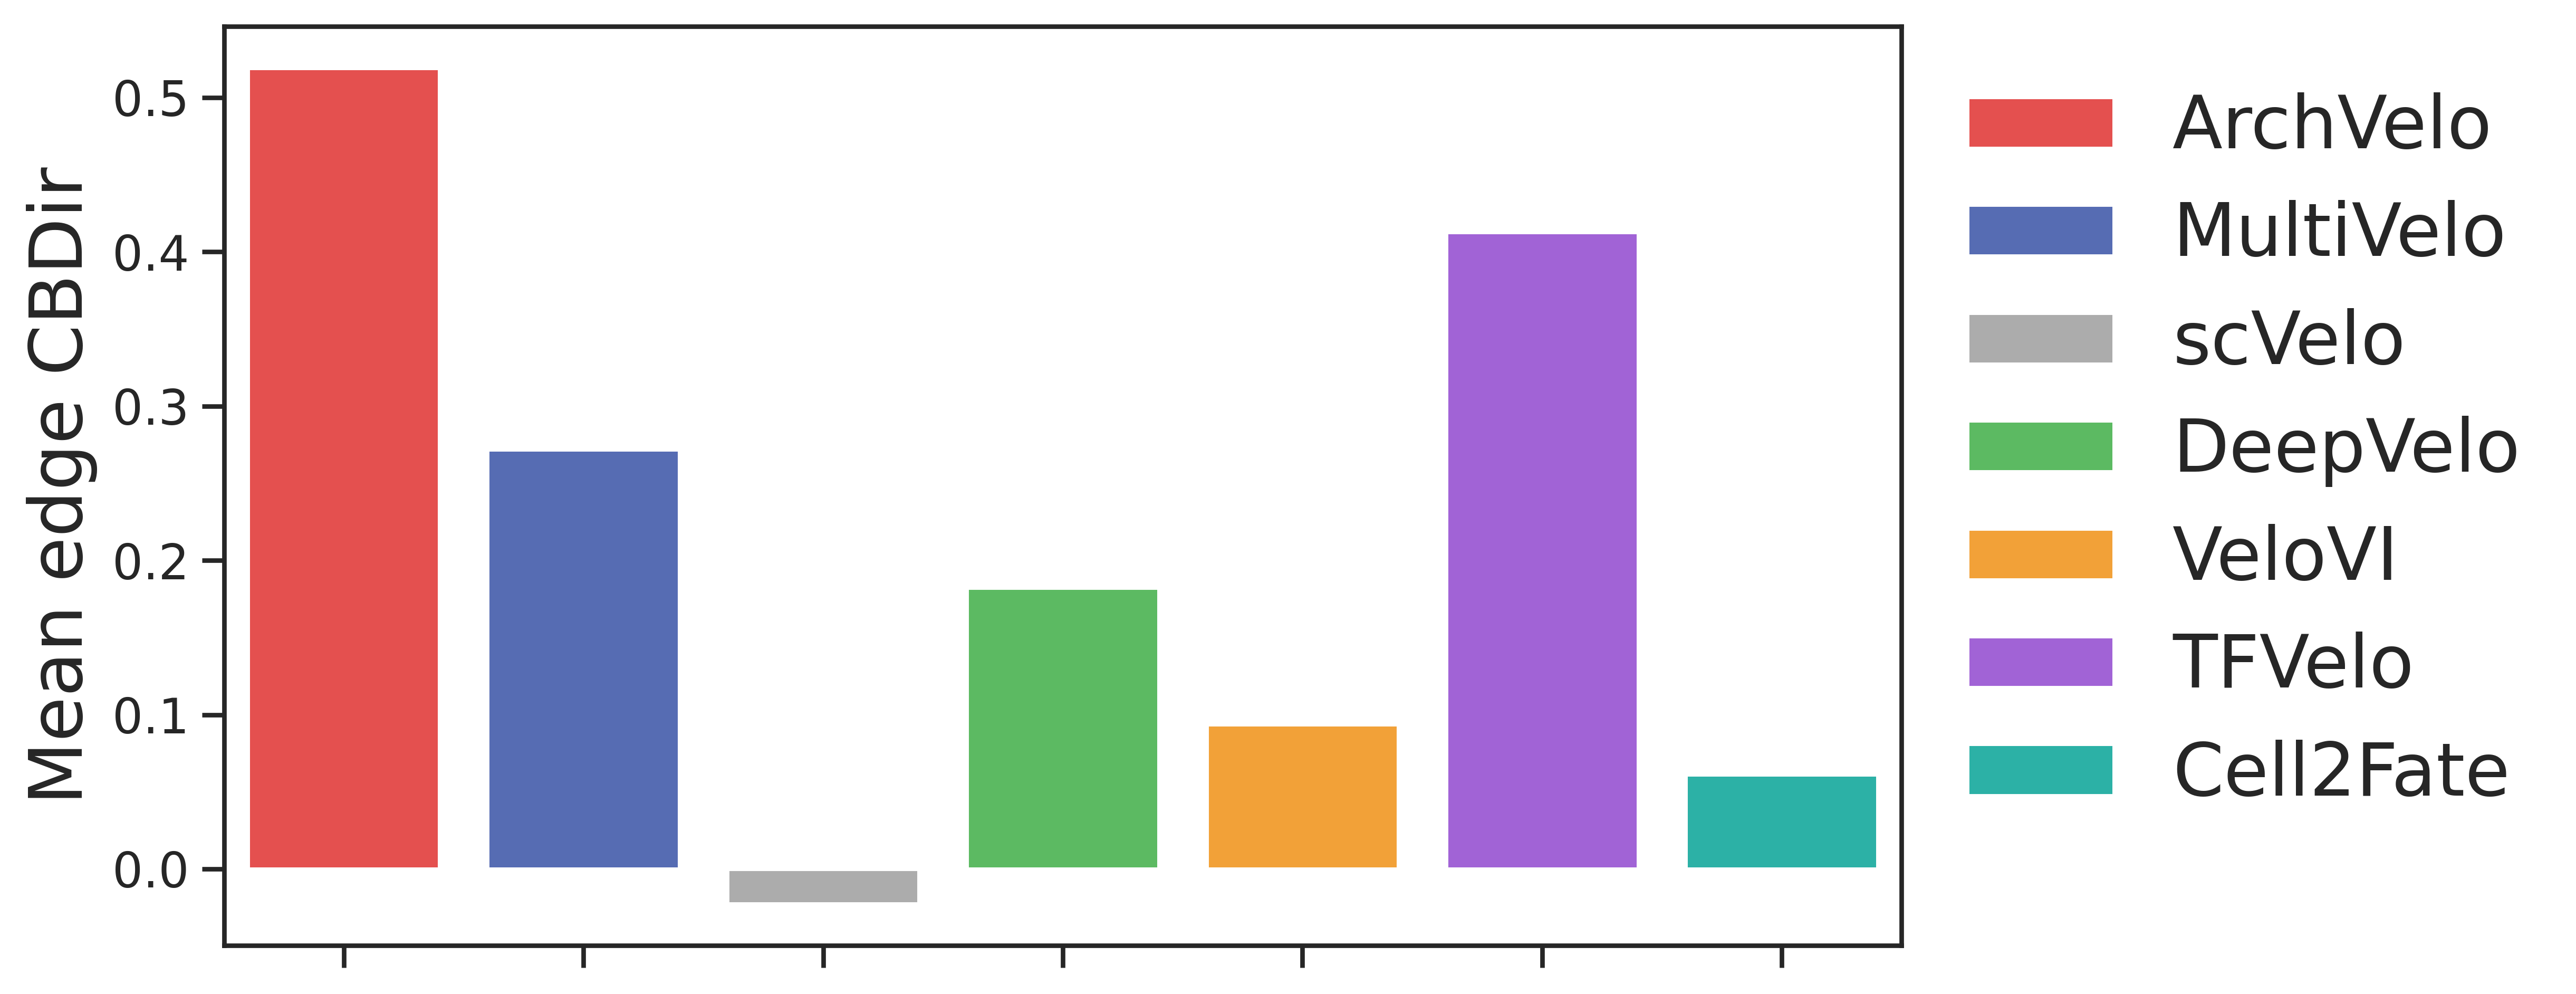

In [27]:
sns.set(style='ticks', font_scale=1.2)
plt.figure(figsize=(10,4), dpi=500)

# 1. Plot the boxplot (hide outliers since we use stripplot for points)
g = sns.barplot(
    data=edge_means, 
    x='Method',
    hue = 'Method',
    y='CBD', 
    palette=pal, 
    hue_order=hue_order, 
    order=hue_order,
    errorbar = None,
    legend = True,
    saturation = 1
)
#plt.xlim(-0.8, 6.8)
plt.ylabel('Mean edge CBDir', fontsize=20)
plt.legend(frameon = False, fontsize =20, bbox_to_anchor = (1,1))
g.set(xticklabels=[])
g.set(xlabel=None)
plt.tight_layout()

plt.savefig(fig_outdir + 'CBCs_barplot_methods.png', dpi = 500,transparent=True)
plt.savefig(fig_outdir + 'CBCs_barplot_methods.svg', dpi = 500, transparent=True)